In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import re
from collections import Counter, defaultdict
from scipy.stats import hypergeom, spearmanr, mannwhitneyu, mstats, chi2_contingency

## Comparing iHS values

Here, we do some pre-processing of the iHS data and select the score for the population we need

In [2]:
ihs_dir = '/mnt/data/phenome_proj/evolution/iHS/'
ihs_data = [x for x in os.listdir(ihs_dir) if x.endswith('.txt')]

In [115]:
testfile = '/mnt/data/phenome_proj/evolution/iHS/chr3.1kg.p3.allPops.iHS.txt'
with open(testfile, 'r') as tt:
    for line in tt:
        if line.startswith('##populations'):
            pop_list = line.strip().split()[2].split('|')
            for idx, pop in enumerate(pop_list):
                print(f'{idx}: {pop}')
            break

0: ESN
1: GWD
2: LWK
3: MSL
4: YRI
5: ACB
6: ASW
7: CLM
8: MXL
9: PEL
10: PUR
11: CDX
12: CHB
13: CHS
14: JPT
15: KHV
16: CEU
17: FIN
18: GBR
19: IBS
20: TSI
21: BEB
22: GIH
23: ITU
24: PJL
25: STU


In [116]:
ihs_dict = {}
for ihsfile in ihs_data:
    with open(f'{ihs_dir}{ihsfile}', 'r') as ihs_handle:
        for line in ihs_handle:
            if line.startswith('#') or 'CHR' in line:
                continue
            content = line.strip().split('\t')
            ihs_value = content[4].split('|')[18]
            if ihs_value == 'NA':
                ihs_value = None
            else:
                ihs_value = np.float64(ihs_value)
            ihs_dict[content[2]] = ihs_value

In [117]:
for ihsfile in ihs_data:
    outfile = ihsfile.replace('txt', 'bed')
    with open(f'{ihs_dir}{ihsfile}', 'r') as ihs_handle, open(f'{ihs_dir}{outfile}', 'w') as out_handle:
        for line in ihs_handle:
            if line.startswith('#') or 'CHR' in line:
                continue
            content = line.strip().split('\t')
            ihs_value = content[4].split('|')[18]
            pos = int(content[1])
            out_handle.write(f'{content[0]}\t{pos - 1}\t{pos + 1}\t{ihs_value}\n')

In [118]:
!cat /mnt/data/phenome_proj/evolution/iHS/*.iHS.bed | \
    sort -k1,1 -k2,2n > /mnt/data/phenome_proj/evolution/iHS/all_iHS.bed

### Case 1. Looking at the exact lead SNP

In [5]:
data_dir = '/mnt/data/phenome_proj/pan_ukb'
file_list = os.listdir(data_dir)
ukb_sumstat = [x for x in file_list if '.bgz' in x]
work_dir = '/mnt/data/phenome_proj/evolution/pan_ukb'
formatted = [x.replace('.bgz', '') for x in ukb_sumstat]

In the following section, I have to correct for the $r_g$ values between pairs of traits to ensure no false labelling of variants as plaiotropic. To do so, I will use the matrix that is exported in the first part of the pleiotropy analysis pipeline.

In [11]:
trait_clustering = pd.read_csv('/mnt/data/phenome_proj/evolution/panukb_clusters.txt', sep='\t')
trait_clustering.index = trait_clustering['pheno_name']
trait_clustering.head()

,pheno_name,cluster
pheno_name,,
continuous-5117,continuous-5117,41
phecode-555,phecode-555,377
continuous-20514,continuous-20514,58
categorical-670,categorical-670,561
categorical-20001,categorical-20001,602


In [12]:
rg_clus = {x: trait_clustering.loc[x, 'cluster'] for x in trait_clustering['pheno_name']}

In [15]:
rg_clus['categorical-670']

561

In [91]:
lead_vars = defaultdict(lambda: set())
for idx, pheno in enumerate([x for x in formatted]):
    in_file = f'{work_dir}/{pheno}.genes.bed'
    try:
        gene_data = pd.read_csv(in_file, sep='\t', header=None)
    except:
#        print('Broke here')
        continue
    gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 
                         'pval', 'chr', 'start', 'end', 'gene_name']
    for rsid in gene_data['rsid']:
        lead_vars[rsid].add(rg_clus[pheno.split('-both_sexes')[0]])

In [92]:
len(vars_pleio)

19166

In [102]:
vars_pleio = pd.DataFrame({'rsid': list(lead_vars.keys()), 
                    'pdeg': list([len(x) for x in lead_vars.values()])})
vars_pleio.head()

,rsid,pdeg
0,rs41494046,1
1,rs201362161,1
2,rs214793,1
3,rs2040445,1
4,rs6025,3


In [100]:
print(Counter(vars_pleio['pdeg']))

Counter({1: 16073, 2: 2166, 3: 528, 4: 204, 5: 86, 6: 43, 7: 19, 8: 12, 9: 10, 10: 6, 15: 4, 13: 4, 16: 3, 11: 2, 18: 1, 26: 1, 14: 1, 19: 1, 12: 1, 20: 1})


In [99]:
print(mstats.mquantiles(vars_pleio['pdeg'], prob=0.75))

[1.]


In [101]:
def emit_group(pdeg):
    if pdeg == 1:
        return 'none'
    elif pdeg <= 3:
        return 'moderate'
    else:
        return 'high'

In [103]:
vars_pleio['pleiotropic'] = [emit_group(x) for x in vars_pleio['pdeg']]
vars_pleio.head()

,rsid,pdeg,pleiotropic
0,rs41494046,1,none
1,rs201362161,1,none
2,rs214793,1,none
3,rs2040445,1,none
4,rs6025,3,moderate


In [120]:
ihs_dict = defaultdict(lambda: None, ihs_dict)

In [121]:
vars_pleio['iHS'] = [ihs_dict[x] for x in vars_pleio['rsid']]

<AxesSubplot:xlabel='pleiotropic', ylabel='iHS'>

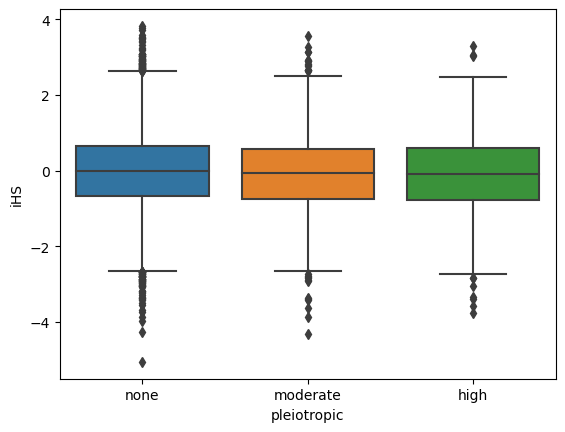

In [122]:
sns.boxplot(data=vars_pleio, x="pleiotropic", y="iHS")

In [123]:
spearmanr(vars_pleio['pdeg'], vars_pleio['iHS'], nan_policy='omit')

SpearmanrResult(correlation=-0.023889279050124262, pvalue=0.00604134667284399)

### Case 2. Looking at the whole locus (100,000)

In [24]:
leads_positions = {}
for idx, pheno in enumerate([x for x in formatted]):
    in_file = f'{work_dir}/{pheno}.genes.bed'
    try:
        gene_data = pd.read_csv(in_file, sep='\t', header=None)
    except:
#        print('Broke here')
        continue
    gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 
                         'pval', 'chr', 'start', 'end', 'gene_name']
    for idx, row in gene_data.iterrows():
        leads_positions[row['rsid']] = (row['var_chr'], row['var_pos'])

In [107]:
hipleio_bed = open('/mnt/data/phenome_proj/evolution/iHS/high_pleio.bed', 'w')
mpleio_bed = open('/mnt/data/phenome_proj/evolution/iHS/moderate_pleio.bed', 'w')
other_bed = open('/mnt/data/phenome_proj/evolution/iHS/other.bed', 'w')
for idx, row in vars_pleio.iterrows():
    var_chr, var_pos = leads_positions[row['rsid']]
    var_pos = int(var_pos)
    out_string = f'{var_chr}\t{var_pos - 50000}\t{var_pos + 50000}\n'
    if row['pleiotropic'] == 'high':
        hipleio_bed.write(out_string)
    elif row['pleiotropic'] == 'moderate':
        mpleio_bed.write(out_string)
    else:
        other_bed.write(out_string)
hipleio_bed.close()
mpleio_bed.close()
other_bed.close()

Preprocessing the loci BEDs before intersecting with the iHS bed

In [108]:
!sort -k1,1 -k2,2n /mnt/data/phenome_proj/evolution/iHS/high_pleio.bed | \
    bedtools merge -i - > /mnt/data/phenome_proj/evolution/iHS/high_pleio_merged.bed

In [109]:
!sort -k1,1 -k2,2n /mnt/data/phenome_proj/evolution/iHS/moderate_pleio.bed | \
    bedtools merge -i - > /mnt/data/phenome_proj/evolution/iHS/moderate_pleio_merged.bed

In [110]:
!sort -k1,1 -k2,2n /mnt/data/phenome_proj/evolution/iHS/other.bed | \
    bedtools merge -i - > /mnt/data/phenome_proj/evolution/iHS/other_merged.bed

Intersecting with the iHS bed constructed earlier

In [124]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/high_pleio_merged.bed \
        -b /mnt/data/phenome_proj/evolution/iHS/all_iHS.bed > \
        /mnt/data/phenome_proj/evolution/iHS/high_pleio_iHS.bed

In [125]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/moderate_pleio_merged.bed \
        -b /mnt/data/phenome_proj/evolution/iHS/all_iHS.bed > \
        /mnt/data/phenome_proj/evolution/iHS/moderate_pleio_iHS.bed

In [126]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/other_merged.bed \
        -b /mnt/data/phenome_proj/evolution/iHS/all_iHS.bed > \
        /mnt/data/phenome_proj/evolution/iHS/other_iHS.bed

Reading the results and plotting

In [133]:
locus_ihs_dict = defaultdict(lambda: defaultdict(lambda: 0))
file_names = ['/mnt/data/phenome_proj/evolution/iHS/high_pleio_iHS.bed',
              '/mnt/data/phenome_proj/evolution/iHS/moderate_pleio_iHS.bed',
              '/mnt/data/phenome_proj/evolution/iHS/other_iHS.bed']
for curr_file in file_names:
    pleio_cat = curr_file.split('/')[-1].split('_')[0]
    print(pleio_cat)
    # Processing the file
    with open(curr_file, 'r') as pihs_handle:
        for line in pihs_handle:
            content = line.strip().split('\t')
            if content[6] == 'NA':
                continue
            ihs_value = float(content[6])
            locus_coords = f'{content[0]}:{content[1]}-{content[2]}'
            if ihs_value > locus_ihs_dict[pleio_cat][locus_coords]:
                locus_ihs_dict[pleio_cat][locus_coords] = ihs_value

type_list = []
value_list = []
for pleio_cat in locus_ihs_dict:
    pleio_cat_names = {'other': "none", 'high': "high", 'moderate': "moderate"}
    type_list.extend([pleio_cat_names[pleio_cat] for _ in locus_ihs_dict[pleio_cat]])
    value_list.extend(list(locus_ihs_dict[pleio_cat].values()))
    
loci_maxihs = pd.DataFrame({'type': type_list,
            'iHS': value_list})
loci_maxihs.head()

high
moderate
other


,type,iHS
0,high,3.253
1,high,3.547
2,high,2.781
3,high,2.230
4,high,3.022


<AxesSubplot:xlabel='type', ylabel='iHS'>

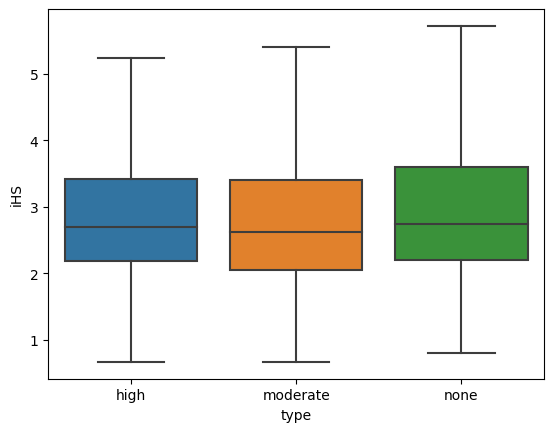

In [134]:
sns.boxplot(data=loci_maxihs, x="type", y="iHS", showfliers=False)

In [135]:
loci_maxihs.to_csv('/mnt/data/phenome_proj/evolution/iHS/locus_maxihs.tsv', 
                   sep='\t', index=False)

## Comparing DRC150 values

In [136]:
asmc_data = pd.read_csv('/mnt/data/phenome_proj/evolution/DRC_150.180813.bed',
                       sep='\t', header=None)

In [137]:
asmc_scores = defaultdict(lambda: None)
for idx, row in asmc_data.iterrows():
    var_name = (row[0], row[2])
    asmc_scores[var_name] = row[3]

In [138]:
vars_pleio['DRC150'] = [asmc_scores[leads_positions[x]] for x in vars_pleio['rsid']]

In [139]:
Counter([np.isnan(x) for x in vars_pleio['DRC150']])

Counter({True: 19157, False: 9})

There's too few variants to analyze, so probably I have to go for the locus-wide analysis. Hence, I have to do the intersection/

In [140]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/high_pleio_merged.bed \
    -b /mnt/data/phenome_proj/evolution/DRC_150.180813.bed > \
    /mnt/data/phenome_proj/evolution/high_pleio_DRC150.bed

In [141]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/moderate_pleio_merged.bed \
    -b /mnt/data/phenome_proj/evolution/DRC_150.180813.bed > \
    /mnt/data/phenome_proj/evolution/moderate_pleio_DRC150.bed

In [142]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/other_merged.bed \
    -b /mnt/data/phenome_proj/evolution/DRC_150.180813.bed > \
    /mnt/data/phenome_proj/evolution/other_DRC150.bed

In [144]:
locus_drc_dict = defaultdict(lambda: defaultdict(lambda: 0))
file_names = ['/mnt/data/phenome_proj/evolution/high_pleio_DRC150.bed',
              '/mnt/data/phenome_proj/evolution/moderate_pleio_DRC150.bed',
              '/mnt/data/phenome_proj/evolution/other_DRC150.bed']
for curr_file in file_names:
    pleio_cat = curr_file.split('/')[-1].split('_')[0]
    print(pleio_cat)
    # Processing the file
    with open(curr_file, 'r') as pdrc_handle:
        for line in pdrc_handle:
            content = line.strip().split('\t')
            if content[6] == 'NA':
                continue
            drc_value = float(content[6])
            locus_coords = f'{content[0]}:{content[1]}-{content[2]}'
            if drc_value > locus_drc_dict[pleio_cat][locus_coords]:
                locus_drc_dict[pleio_cat][locus_coords] = drc_value

type_list = []
value_list = []
for pleio_cat in locus_drc_dict:
    pleio_cat_names = {'other': "none", 'high': "high", 'moderate': "moderate"}
    type_list.extend([pleio_cat_names[pleio_cat] for _ in locus_drc_dict[pleio_cat]])
    value_list.extend(list(locus_drc_dict[pleio_cat].values()))
    
loci_maxdrc = pd.DataFrame({'type': type_list,
            'DRC150': value_list})
loci_maxdrc.head()

high
moderate
other


,type,DRC150
0,high,0.001273
1,high,0.001353
2,high,0.002402
3,high,0.001338
4,high,0.001962


<AxesSubplot:xlabel='type', ylabel='DRC150'>

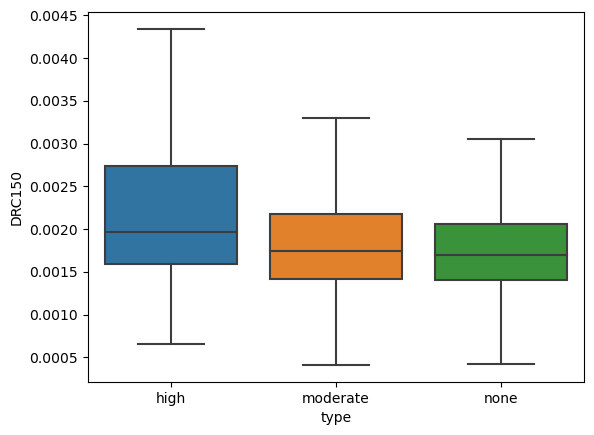

In [145]:
sns.boxplot(data=loci_maxdrc, x="type", y="DRC150", showfliers=False)

In [146]:
loci_maxdrc.to_csv('/mnt/data/phenome_proj/evolution/iHS/locus_maxdrc.tsv', 
                   sep='\t', index=False)

## Comparison of the phastCons scores

In [147]:
!perl -pe 's|^|chr|' /mnt/data/phenome_proj/evolution/iHS/high_pleio_merged.bed \
    > /mnt/data/phenome_proj/evolution/iHS/high_pleio_merged_withChr.bed

In [148]:
!perl -pe 's|^|chr|' /mnt/data/phenome_proj/evolution/iHS/moderate_pleio_merged.bed \
    > /mnt/data/phenome_proj/evolution/iHS/moderate_pleio_merged_withChr.bed

In [149]:
!perl -pe 's|^|chr|' /mnt/data/phenome_proj/evolution/iHS/other_merged.bed \
    > /mnt/data/phenome_proj/evolution/iHS/other_merged_withChr.bed

In [150]:
!/mnt/data/phenome_proj/evolution/phastCons/isec_phastCons.sh \
    /mnt/data/phenome_proj/evolution/iHS/high_pleio_merged_withChr.bed \
    /mnt/data/phenome_proj/evolution/phastCons/high_pleio_phastCons

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, done! Merging...


In [151]:
!/mnt/data/phenome_proj/evolution/phastCons/isec_phastCons.sh \
    /mnt/data/phenome_proj/evolution/iHS/moderate_pleio_merged_withChr.bed \
    /mnt/data/phenome_proj/evolution/phastCons/moderate_pleio_phastCons

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, done! Merging...


In [152]:
!/mnt/data/phenome_proj/evolution/phastCons/isec_phastCons.sh \
    /mnt/data/phenome_proj/evolution/iHS/other_merged_withChr.bed \
    /mnt/data/phenome_proj/evolution/phastCons/other_phastCons

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, done! Merging...


In [163]:
locus_phc_dict = defaultdict(lambda: defaultdict(lambda: []))
file_names = ['/mnt/data/phenome_proj/evolution/phastCons/high_pleio_phastCons.bed',
              '/mnt/data/phenome_proj/evolution/phastCons/moderate_pleio_phastCons.bed',
              '/mnt/data/phenome_proj/evolution/phastCons/other_phastCons.bed']
for curr_file in file_names:
    pleio_cat = curr_file.split('/')[-1].split('_')[0]
    print(pleio_cat)
    # Processing the file
    with open(curr_file, 'r') as pphc_handle:
        for line in pphc_handle:
            content = line.strip().split('\t')
#            locus_length = int(content[6]) - int(content[5])
            phc_value = float(content[3]) # /locus_length
            locus_coords = f'{content[4]}:{content[5]}-{content[6]}'
            locus_phc_dict[pleio_cat][locus_coords].append(phc_value)

type_list = []
value_list = []
for pleio_cat in locus_phc_dict:
    pleio_cat_names = {'other': "none", 'high': "high", 'moderate': "moderate"}
    type_list.extend([pleio_cat_names[pleio_cat] for _ in locus_phc_dict[pleio_cat]])
    score_lists = list(locus_phc_dict[pleio_cat].values())
    averaged_scores = [np.mean(x) for x in score_lists]
    value_list.extend(averaged_scores)
    
loci_meanphc = pd.DataFrame({'type': type_list,
            'phastCons': value_list})
loci_meanphc.head()

high
moderate
other


,type,phastCons
0,high,0.112738
1,high,0.112419
2,high,0.131693
3,high,0.109431
4,high,0.174585


<AxesSubplot:xlabel='type', ylabel='phastCons'>

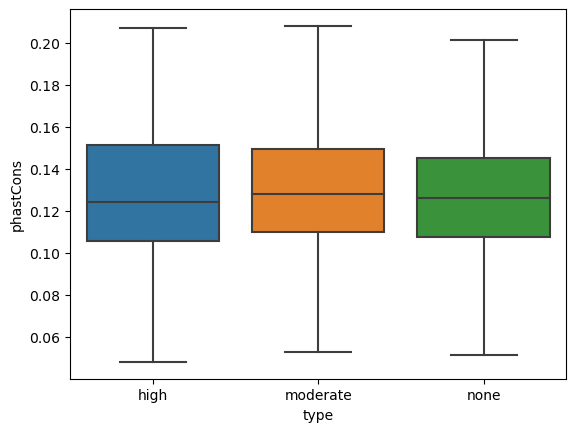

In [164]:
sns.boxplot(data=loci_meanphc, x="type", y="phastCons", showfliers=False)

In [165]:
loci_meanphc.groupby('type').mean()

,phastCons
type,
high,0.129236
moderate,0.130978
none,0.127260


In [166]:
loci_meanphc.to_csv('/mnt/data/phenome_proj/evolution/phastCons/locus_meanphc.tsv',
                   sep='\t', index=False)

## Computing gene-level selection metrics

### Averaging phastCons over CDS

The `average_phastCons_over_gene.sh` is used to get scores for each CDS of each gene (a 5-col file per each chromosome). Here, we will process these to make a single gene average table and then export it.

In [167]:
! cat /mnt/data/phenome_proj/evolution/phastCons/chr*cds_isec.txt \
    > /mnt/data/phenome_proj/evolution/phastCons/all.cds_isec.txt

In [168]:
comb_file = '/mnt/data/phenome_proj/evolution/phastCons/all.cds_isec.txt'
cds_pc_scores = pd.read_csv(comb_file, sep='\t', header=None)
cds_pc_scores.head()

,0,1,2,3,4
0,chr10,92999,93000,0.442,TUBB8
1,chr10,93000,93001,0.911,TUBB8
2,chr10,93001,93002,0.910,TUBB8
3,chr10,93002,93006,0.000,TUBB8
4,chr10,93006,93007,0.990,TUBB8


In [169]:
cds_pc_scores.columns = ['chr', 'start', 'end', 'score', 'gene']

In [172]:
avg_cds_scores = pd.DataFrame(cds_pc_scores.groupby('gene')['score'].mean())
avg_cds_scores.head()

,score
gene,
A1BG,0.162894
A1CF,0.752174
A2M,0.497688
A2ML1,0.476872
A3GALT2,0.529357


In [173]:
avg_cds_scores.to_csv('/mnt/data/phenome_proj/evolution/phastCons/phastCons_cds_averages.tsv', sep='\t')

### Making gene-level maximum iHS and DRC150 values

An earlier version of the method used shell tools like `awk` to construct the scores. I re-implement it using shell + Pandas for clarity

In [174]:
genemax_dir=  '/mnt/data/phenome_proj/evolution/gene_max_stats'

In [175]:
!sort -k1,1 -k2,2n /mnt/data/phenome_proj/evolution/gene_max_stats/DRC_150.180813.bed \
    > /mnt/data/phenome_proj/evolution/gene_max_stats/DRC150.sorted.bed

In [177]:
# iHS
!bedtools closest -a /mnt/data/phenome_proj/evolution/gene_max_stats/all_iHS.bed \
    -b /mnt/data/phenome_proj/evolution/gene_max_stats/gencode_formatted.bed \
    > /mnt/data/phenome_proj/evolution/gene_max_stats/iHS_closest_genes.tsv

In [178]:
# DRC150
!bedtools closest -a /mnt/data/phenome_proj/evolution/gene_max_stats/DRC150.sorted.bed \
    -b /mnt/data/phenome_proj/evolution/gene_max_stats/gencode_formatted.bed \
    > /mnt/data/phenome_proj/evolution/gene_max_stats/DRC150_closest_genes.tsv

In [179]:
ihs_clfile = '/mnt/data/phenome_proj/evolution/gene_max_stats/iHS_closest_genes.tsv'
ihs_close = pd.read_csv(ihs_clfile, sep='\t', header=None)
ihs_close.columns = ['chr', 'start', 'end', 'ihs', 
                     'chr_gene', 'start_gene', 'end_gene', 'gene_name']
ihs_close.head()

/tmp/ipykernel_3333255/313551702.py:2: DtypeWarning: Columns (0,4) have mixed types. Specify dtype option on import or set low_memory=False.
  ihs_close = pd.read_csv(ihs_clfile, sep='\t', header=None)


,chr,start,end,ihs,chr_gene,start_gene,end_gene,gene_name
0,1,14929,14931,NaN,1,14363,29806,WASH7P
1,1,14932,14934,NaN,1,14363,29806,WASH7P
2,1,15210,15212,NaN,1,14363,29806,WASH7P
3,1,15773,15775,NaN,1,14363,29806,WASH7P
4,1,30922,30924,NaN,1,29554,31109,MIR1302-11


In [181]:
max_gene_ihs = pd.DataFrame(ihs_close.groupby('gene_name')['ihs'].max())
max_gene_ihs.head()

,ihs
gene_name,
5S_rRNA,2.686
7SK,2.333
A1BG,0.720
A1BG-AS1,0.767
A1CF,1.741


In [182]:
ihs_out_file = f'{genemax_dir}/max_gene_ihs.tsv'
max_gene_ihs.to_csv(ihs_out_file, sep='\t')

In [184]:
drc_clfile = '/mnt/data/phenome_proj/evolution/gene_max_stats/DRC150_closest_genes.tsv'
drc_close = pd.read_csv(drc_clfile, sep='\t', header=None)
drc_close.columns = ['chr', 'start', 'end', 'DRC150', 'DRC150_pval',
                     'chr_gene', 'start_gene', 'end_gene', 'gene_name']
max_gene_drc = pd.DataFrame(drc_close.groupby('gene_name')['DRC150'].max())
max_gene_drc.head()

,DRC150
gene_name,
7SK,0.001891
A1CF,0.001786
A2M,0.001704
A2ML1,0.001679
A2ML1-AS1,0.001601


In [185]:
drc_out_file = f'{genemax_dir}/max_gene_DRC150.tsv'
max_gene_drc.to_csv(drc_out_file, sep='\t')

## Checking for interval size confounding

It may be hypothesized that the observed enrichment with high scores (both iHS and DRC150) may arise from the larger interval sizes. To test for this, the simplest option is to just compute the average size of an interval in a group:

In [186]:
!for i in /mnt/data/phenome_proj/evolution/iHS/*merged.bed ; \
    do echo $i ; awk '{ sum+=$3-$2 } END { print sum/NR }' $i ; done

/mnt/data/phenome_proj/evolution/iHS/high_pleio_merged.bed
118747
/mnt/data/phenome_proj/evolution/iHS/moderate_pleio_merged.bed
131373
/mnt/data/phenome_proj/evolution/iHS/other_merged.bed
173615


The same procedure could be performed for genes in the highly pleiotropic category

In [187]:
gencode_bed = '/mnt/data/phenome_proj/evolution/gencode_formatted.bed'
gene_data = pd.read_csv(gencode_bed, sep='\t', header=None)
gene_data.columns = ['chr', 'start', 'end', 'gene_name']
gene_data['gene_size'] = [int(x) - int(y) for x, y in zip(gene_data['end'], 
                                                          gene_data['start'])]
gene_data.head()

,chr,start,end,gene_name,gene_size
0,1,11869,14412,DDX11L1,2543
1,1,14363,29806,WASH7P,15443
2,1,29554,31109,MIR1302-11,1555
3,1,34554,36081,FAM138A,1527
4,1,52473,54936,OR4G4P,2463


In [188]:
pleio_file = '/mnt/data/phenome_proj/evolution/non_hla_panukb_pleiotropy_allTypes.tsv'
gene_pleiotropy = pd.read_csv(pleio_file, sep='\t')
gene_pleiotropy.head()

,gene_name,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide
0,AL109843.1,NaN,NaN,1.0
1,RNU4ATAC4P,NaN,NaN,1.0
2,RP4-763G1.1,NaN,NaN,1.0
3,C1orf141,NaN,NaN,1.0
4,IL23R,1.0,NaN,1.0


In [189]:
merged_gene_data = gene_data.merge(gene_pleiotropy, on='gene_name')
merged_gene_data.head()

,chr,start,end,gene_name,gene_size,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide
0,1,1017198,1051741,C1orf159,34543,NaN,NaN,1.0
1,1,1072397,1079436,RP11-465B22.5,7039,1.0,1.0,1.0
2,1,1102484,1102578,MIR200B,94,NaN,NaN,1.0
3,1,1103243,1103332,MIR200A,89,NaN,NaN,1.0
4,1,1104385,1104467,MIR429,82,NaN,NaN,1.0


In [190]:
merged_gene_data['group'] = [emit_group(x) for x in merged_gene_data['pleio_degree']]

<AxesSubplot:xlabel='group', ylabel='gene_size'>

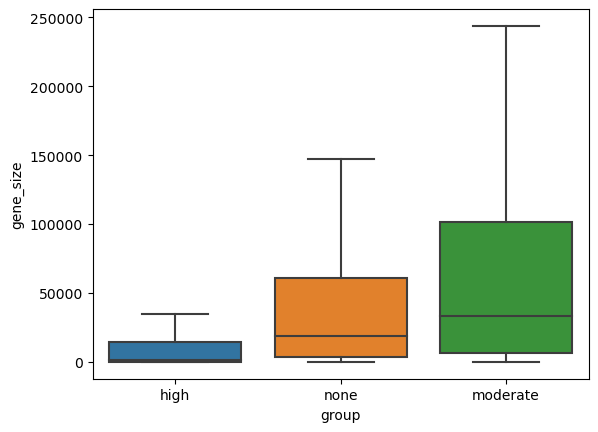

In [191]:
sns.boxplot(data=merged_gene_data, x="group", y="gene_size", showfliers=False)

The highly pleiotropic genes actually tend to be shorter, even than the non-pleiotropic ones (to which we compare them in the tedsts). So it seems that size is not a real confounder of the results.